# 09 - Systematic Error Analysis (ContraDoc)

This notebook drills into where the cascade pipeline (Vector+Structural -> NLI-FT@0.5 -> LLM-Sonnet) makes mistakes, so we can attribute errors to specific stages and identify systematic gaps vs annotation issues.

## Sections
1. **Stage attribution** - for each missed gold pair, which stage killed it? (retrieval / NLI / LLM)
2. **Per-type failure modes** - which contradiction types are hardest at each stage?
3. **NLI score distribution** - how separable are TP/FP/FN by NLI confidence?
4. **False-negative samples** - random samples of missed gold pairs from each stage
5. **False-positive samples** - random samples of LLM-flagged-but-not-gold pairs (with LLM explanations)
6. **Cherry-picked failures** - hand-selected representative pairs with stage-specific diagnoses (defense slide material)
7. **Inter-judge agreement** - Sonnet vs Haiku verdict matrix on the same 297 candidate pairs (annotation-gap signal)
8. **FP concentration by document** - is FP rate uniform or clustered in a few docs?
9. **Per-doc recall distribution** - all-or-nothing recall vs smooth distribution
10. **Retrieval channel credit** - where do caught pairs come from: vector / struct / both?
11. **Per-type performance** - precision/recall/F1 by contradiction type (gold-doc-type vs LLM-predicted-type asymmetry)

## Inputs
- `predictions_ablation.jsonl` (per-pair NLI scores from notebook 07)
- `llm_cascade_sonnet.jsonl` and `llm_cascade_haiku.jsonl` (per-pair LLM judgments from notebook 08)
- `triples_minie.jsonl` (gold + per-doc contradiction type)

## Outputs
- `data/processed/ContraDoc/error_samples_fn.md` - false negative samples
- `data/processed/ContraDoc/error_samples_fp.md` - false positive samples
- Plots in `plots/09_error_analysis/`:
  - `stage_attribution.png` (Section 1)
  - `per_type_failure.png` (Section 2)
  - `nli_score_distribution.png` (Section 3)
  - `interjudge_agreement.png` (Section 7)
  - `fp_concentration.png` + `fp_top_docs.png` (Section 8)
  - `per_doc_recall.png` + `per_doc_recall_outcomes.png` (Section 9)
  - `retrieval_channel_credit.png` (Section 10)
  - `per_type_performance.png` (Section 11)


In [1]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

PRED_PATH        = Path("data/processed/ContraDoc/predictions_ablation.jsonl")
CASCADE_SON_PATH = Path("data/processed/ContraDoc/llm_cascade_sonnet.jsonl")
TRIPLES_PATH     = Path("data/processed/ContraDoc/triples_minie.jsonl")
PLOT_DIR         = Path("plots/09_error_analysis")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CASCADE_NLI_THRESHOLD = 0.5
random.seed(42)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 13, "axes.titlesize": 15, "axes.labelsize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "figure.titlesize": 15, "axes.spines.top": False, "axes.spines.right": False,
})

# --- Load ---
preds = [json.loads(l) for l in PRED_PATH.open(encoding="utf-8")]
cascade = [json.loads(l) for l in CASCADE_SON_PATH.open(encoding="utf-8")]
print(f"Loaded {len(preds):,} predictions, {len(cascade)} cascade judgments")

docs = {}
with TRIPLES_PATH.open(encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        docs[r["doc_id"]] = {
            "contradiction": r["contradiction"],
            "contra_type":   r.get("contra_type") or "",
            "gold_evidence_sentence_id": r.get("gold_evidence_sentence_id"),
            "gold_ref_sentence_ids":     r.get("gold_ref_sentence_ids") or [],
            "sentences": [(s["sentence_id"], s["source_text"]) for s in r["sentences"]],
        }
n_docs = len(docs)


def pkey(a, b):
    return (a, b) if a < b else (b, a)


gold_pairs = set()
for doc_id, d in docs.items():
    ev = d["gold_evidence_sentence_id"]
    if d["contradiction"] != "YES" or ev is None or not d["gold_ref_sentence_ids"]:
        continue
    for ref in d["gold_ref_sentence_ids"]:
        if ev == ref:
            continue
        gold_pairs.add(pkey((doc_id, ev), (doc_id, ref)))
n_gold = len(gold_pairs)
print(f"Gold pairs: {n_gold} across {len({p[0][0] for p in gold_pairs})} docs")

# Per-pair lookups
preds_by_pair = {}
for p in preds:
    k = pkey((p["doc_id"], p["chunk_a"]["sentence_id"]),
             (p["doc_id"], p["chunk_b"]["sentence_id"]))
    preds_by_pair[k] = p

cascade_by_pair = {}
for r in cascade:
    k = pkey((r["doc_id"], r["chunk_a"]["sentence_id"]),
             (r["doc_id"], r["chunk_b"]["sentence_id"]))
    cascade_by_pair[k] = r

doc_types = {
    d_id: [t for t in d["contra_type"].split("|") if t]
    for d_id, d in docs.items() if d["contradiction"] == "YES"
}

Loaded 122,802 predictions, 297 cascade judgments
Gold pairs: 122 across 118 docs


## 1. Stage attribution: where do gold pairs die?

For each of the `n_gold` gold pairs, classify which stage of the cascade pipeline killed it:

- `retrieval_miss` - not in Vector+Structural retrieval (so never seen)
- `nli_miss` - in retrieval but NLI-FT score < 0.5 (filtered out before LLM)
- `llm_reject` - NLI-FT >= 0.5 but LLM said "not contradiction"
- `caught` - LLM accepted (true positive)

The narrative this answers: "if the cascade misses 60 gold pairs, where do they go?"


Total gold: 122

Stage               Count    Pct
--------------------------------
retrieval_miss         46 37.7%
nli_miss               14 11.5%
llm_reject              0  0.0%
caught                 62 50.8%


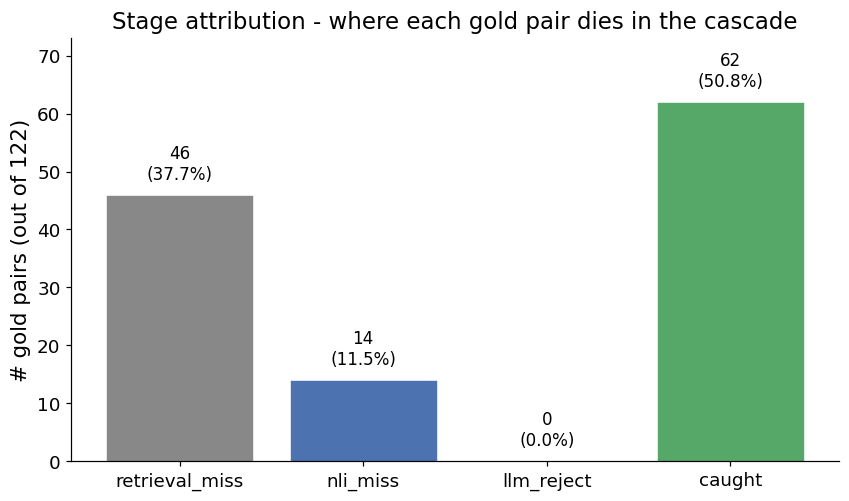

In [2]:
def stage_for(gold_pair):
    p = preds_by_pair.get(gold_pair)
    if p is None or not (p["in_struct"] or p["in_vector"]):
        return "retrieval_miss"
    if p["nli_ft_contradiction"] < CASCADE_NLI_THRESHOLD:
        return "nli_miss"
    cas = cascade_by_pair.get(gold_pair)
    if cas is None:
        return "nli_miss"  # didn't reach LLM
    if not cas["llm_is_contradiction"]:
        return "llm_reject"
    return "caught"


stage_for_gp = {gp: stage_for(gp) for gp in gold_pairs}
stage_counts = Counter(stage_for_gp.values())

stage_order = ["retrieval_miss", "nli_miss", "llm_reject", "caught"]
print(f"Total gold: {n_gold}\n")
print(f"{'Stage':<18} {'Count':>6} {'Pct':>6}")
print("-" * 32)
for s in stage_order:
    c = stage_counts.get(s, 0)
    print(f"{s:<18} {c:>6} {c / n_gold:>5.1%}")

# Bar plot
stage_colors = {
    "retrieval_miss": "#888888",
    "nli_miss":       "#4C72B0",
    "llm_reject":     "#C44E52",
    "caught":         "#55A868",
}
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    stage_order,
    [stage_counts.get(s, 0) for s in stage_order],
    color=[stage_colors[s] for s in stage_order],
    edgecolor="white", linewidth=0.4,
)
for bar, s in zip(bars, stage_order):
    c = stage_counts.get(s, 0)
    ax.text(bar.get_x() + bar.get_width() / 2, c + max(2, n_gold * 0.01),
            f"{c}\n({c / n_gold:.1%})",
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel(f"# gold pairs (out of {n_gold})")
ax.set_title("Stage attribution - where each gold pair dies in the cascade")
ax.set_ylim(0, max(stage_counts.values()) * 1.18)
fig.savefig(PLOT_DIR / "stage_attribution.png")
plt.show()

## 2. Per-type failure modes

For each contradiction type (Numeric / Negation / Content / etc.), break down where its gold pairs die. This tells us which types are systematically lost at retrieval vs at NLI vs at LLM.


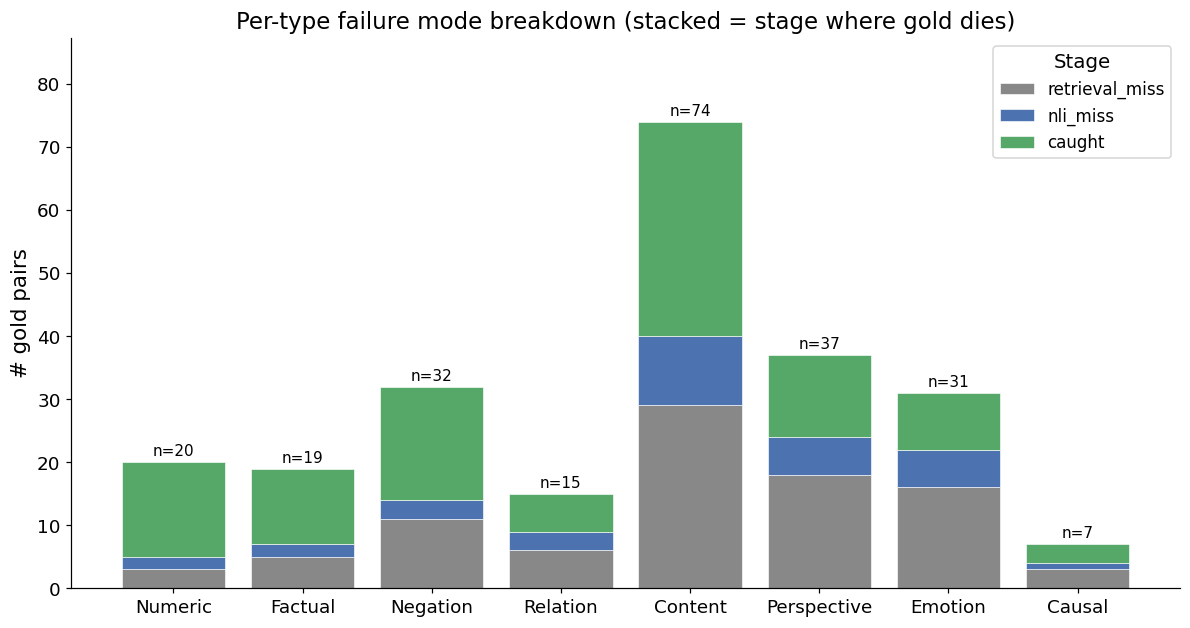


Type                            n  caught  recall  lost@retr  lost@NLI  lost@LLM
--------------------------------------------------------------------------------
Numeric                        20      15  75.0%          3         2         0
Factual                        19      12  63.2%          5         2         0
Negation                       32      18  56.2%         11         3         0
Relation                       15       6  40.0%          6         3         0
Content                        74      34  45.9%         29        11         0
Perspective/View/Opinion       37      13  35.1%         18         6         0
Emotion/Mood/Feeling           31       9  29.0%         16         6         0
Causal                          7       3  42.9%          3         1         0


In [3]:
type_order = ["Numeric", "Factual", "Negation", "Relation",
              "Content", "Perspective/View/Opinion", "Emotion/Mood/Feeling", "Causal"]

per_type = defaultdict(lambda: Counter())
for gp, stage in stage_for_gp.items():
    doc_id = gp[0][0]
    for t in doc_types.get(doc_id, []):
        if t in type_order:
            per_type[t][stage] += 1

# Stacked bar: per type, fraction lost at each stage
short = {"Perspective/View/Opinion": "Perspective", "Emotion/Mood/Feeling": "Emotion"}
fig, ax = plt.subplots(figsize=(13, 6.5))
x = np.arange(len(type_order))
bottom = np.zeros(len(type_order))
for s in stage_order:
    vals = np.array([per_type[t].get(s, 0) for t in type_order])
    if vals.sum() == 0:
        continue
    ax.bar(x, vals, bottom=bottom, color=stage_colors[s], edgecolor="white",
           linewidth=0.4, label=s)
    bottom += vals
totals = [sum(per_type[t].values()) for t in type_order]
for i, t in enumerate(type_order):
    ax.text(x[i], totals[i] + 0.5, f"n={totals[i]}", ha="center", va="bottom",
            fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([short.get(t, t) for t in type_order], rotation=0)
ax.set_ylabel("# gold pairs")
ax.set_title("Per-type failure mode breakdown (stacked = stage where gold dies)")
ax.legend(loc="upper right", title="Stage")
ax.set_ylim(0, max(totals) * 1.18 if totals else 5)
fig.savefig(PLOT_DIR / "per_type_failure.png")
plt.show()

# Print per-type recall by stage
print(f"\n{'Type':<28} {'n':>4} {'caught':>7} {'recall':>7} {'lost@retr':>10} {'lost@NLI':>9} {'lost@LLM':>9}")
print("-" * 80)
for t in type_order:
    cnt = per_type[t]
    n = sum(cnt.values())
    if n == 0:
        continue
    caught = cnt.get("caught", 0)
    print(f"{t:<28} {n:>4} {caught:>7} {caught / n:>6.1%} "
          f"{cnt.get('retrieval_miss', 0):>10} {cnt.get('nli_miss', 0):>9} "
          f"{cnt.get('llm_reject', 0):>9}")

## 3. NLI score distribution

Histogram of NLI-FT contradiction scores for:
- Gold pairs (true contradictions)
- Non-gold pairs (in retrieval pool)

Also overlay the cascade threshold (0.5) and the F1-best threshold (0.941) so we can see how separable the model thinks gold is vs not.


In-retrieval pool: 3,635 pairs
  Gold:        76  (mean P_contra=0.771)
  Non-gold:  3559  (mean P_contra=0.081)


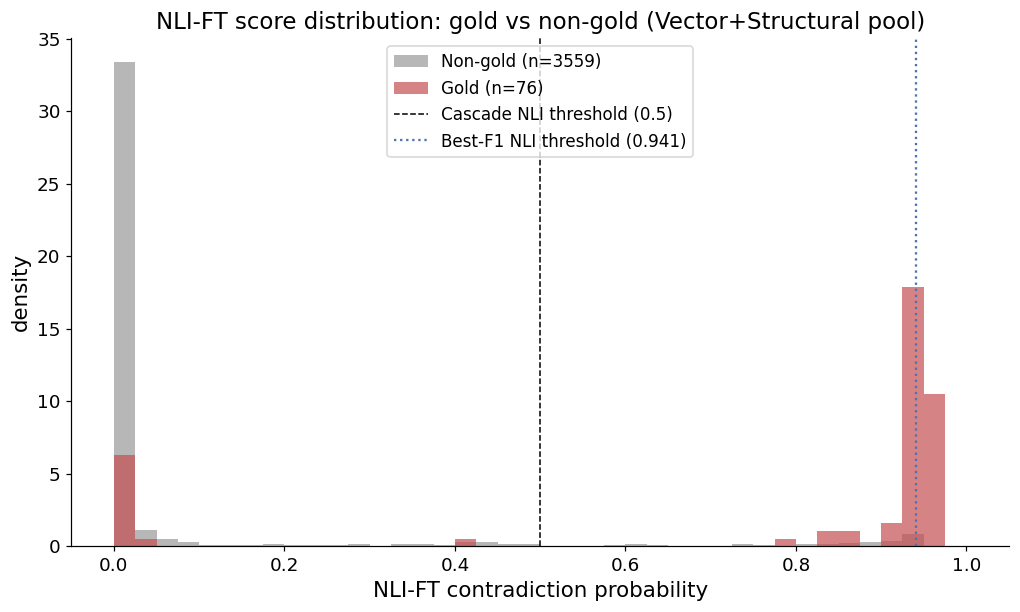

In [4]:
# Restrict to Vector+Structural retrieval pool (the cascade input universe)
in_retrieval = [p for p in preds if p["in_struct"] or p["in_vector"]]
gold_scores  = np.array([p["nli_ft_contradiction"] for p in in_retrieval if p["is_gold_pair"]])
nogold_scores = np.array([p["nli_ft_contradiction"] for p in in_retrieval if not p["is_gold_pair"]])

print(f"In-retrieval pool: {len(in_retrieval):,} pairs")
print(f"  Gold:     {len(gold_scores):>5}  (mean P_contra={gold_scores.mean():.3f})")
print(f"  Non-gold: {len(nogold_scores):>5}  (mean P_contra={nogold_scores.mean():.3f})")

fig, ax = plt.subplots(figsize=(11, 6))
bins = np.linspace(0, 1, 41)
ax.hist(nogold_scores, bins=bins, color="#888888", alpha=0.6, label=f"Non-gold (n={len(nogold_scores)})", density=True)
ax.hist(gold_scores,   bins=bins, color="#C44E52", alpha=0.7, label=f"Gold (n={len(gold_scores)})",        density=True)
ax.axvline(0.5,   color="black", linestyle="--", linewidth=1, label="Cascade NLI threshold (0.5)")
ax.axvline(0.941, color="#4C72B0", linestyle=":",  linewidth=1.5, label="Best-F1 NLI threshold (0.941)")
ax.set_xlabel("NLI-FT contradiction probability")
ax.set_ylabel("density")
ax.set_title("NLI-FT score distribution: gold vs non-gold (Vector+Structural pool)")
ax.legend(loc="upper center")
fig.savefig(PLOT_DIR / "nli_score_distribution.png")
plt.show()

## 4. False negative samples - what is the cascade missing?

Sample missed gold pairs from each stage to inspect. This is qualitative — the goal is to *see* what's being missed, not aggregate.

Saved to `error_samples_fn.md` for later review.


In [5]:
fn_pairs = {gp: s for gp, s in stage_for_gp.items() if s != "caught"}
print(f"Total false negatives: {len(fn_pairs)}")
print(f"  retrieval_miss: {sum(1 for s in fn_pairs.values() if s == 'retrieval_miss')}")
print(f"  nli_miss:       {sum(1 for s in fn_pairs.values() if s == 'nli_miss')}")
print(f"  llm_reject:     {sum(1 for s in fn_pairs.values() if s == 'llm_reject')}")

SAMPLE_PER_STAGE = 5
samples_by_stage = defaultdict(list)
for gp, s in fn_pairs.items():
    samples_by_stage[s].append(gp)

samples = []
for s in ("retrieval_miss", "nli_miss", "llm_reject"):
    pool = samples_by_stage[s]
    random.shuffle(pool)
    samples.extend((s, gp) for gp in pool[:SAMPLE_PER_STAGE])

OUT_FN = Path("data/processed/ContraDoc/error_samples_fn.md")
OUT_FN.parent.mkdir(parents=True, exist_ok=True)
md_lines = ["# False-negative samples (cascade pipeline missed these gold pairs)\n"]
for stage, gp in samples:
    (doc_id, sa), (_, sb) = sorted(gp)
    text_a = dict(docs[doc_id]["sentences"]).get(sa, "<missing>")
    text_b = dict(docs[doc_id]["sentences"]).get(sb, "<missing>")
    p = preds_by_pair.get(gp)
    nli_score = p["nli_ft_contradiction"] if p else None
    in_struct = p["in_struct"] if p else False
    in_vector = p["in_vector"] if p else False
    cas = cascade_by_pair.get(gp)
    types = doc_types.get(doc_id, [])

    print(f"\n[stage={stage}]  doc={doc_id}  types={'|'.join(types)}")
    print(f"  A [{sa}]: {text_a[:140]}")
    print(f"  B [{sb}]: {text_b[:140]}")
    if p:
        print(f"  NLI-FT P(contra)={nli_score:.3f}   in_struct={in_struct}  in_vector={in_vector}")
    if cas:
        print(f"  LLM said is_contradiction={cas['llm_is_contradiction']}  reason: {cas['llm_explanation']}")

    md_lines.append(f"## stage = {stage}  -  {doc_id}  -  types: {'|'.join(types)}\n")
    md_lines.append(f"- A [sid={sa}]: {text_a}\n")
    md_lines.append(f"- B [sid={sb}]: {text_b}\n")
    if p:
        md_lines.append(f"- NLI-FT P(contra) = **{nli_score:.3f}**  in_struct={in_struct} in_vector={in_vector}\n")
    if cas:
        md_lines.append(f"- LLM `is_contradiction`={cas['llm_is_contradiction']}  type={cas.get('llm_contradiction_type')}  conf={cas.get('llm_confidence')}\n")
        md_lines.append(f"- LLM reason: {cas['llm_explanation']}\n")
    md_lines.append("\n---\n")

OUT_FN.write_text("".join(md_lines), encoding="utf-8")
print(f"\nWrote {len(samples)} FN samples -> {OUT_FN.resolve()}")

Total false negatives: 60
  retrieval_miss: 46
  nli_miss:       14
  llm_reject:     0

[stage=retrieval_miss]  doc=3489825766_2  types=Content|Perspective/View/Opinion
  A [3]: But it was the opposition from Walmart, the ubiquitous retailer that dots the American landscape, that perhaps resonated most deeply, provid
  B [4]: Walmart's staunch criticism of a religious freedom law in its home state of Arkansas came after the company said in February it would boost 
  NLI-FT P(contra)=0.004   in_struct=False  in_vector=False

[stage=retrieval_miss]  doc=3488771838_4  types=Emotion/Mood/Feeling
  A [11]: Tom Thumb discovers the food is plaster and finds it amusing.
  B [12]: The two smash every dish on the table – "bang, bang, smash, smash!" – and even try to burn one in the "red-hot crinkly paper fire" in the ki
  NLI-FT P(contra)=0.004   in_struct=False  in_vector=False

[stage=retrieval_miss]  doc=3489738259_4  types=Content|Perspective/View/Opinion|Relation
  A [7]: The much anticipa

## 5. False positive samples - LLM-flagged-but-not-gold

These are pairs the cascade flagged as contradictions but that aren't in the gold set. Three buckets to keep in mind when manually reviewing:

1. **Real but unannotated** - an actual contradiction the dataset just didn't label (annotation gap)
2. **Topical overlap** - sentences sharing vocabulary that the LLM mistook for a conflict
3. **LLM hallucination** - LLM invented a conflict that isn't there

We can't auto-classify these without manual review. The notebook saves them to `error_samples_fp.md` with the LLM's own explanation so you can read through them.

Sorted by LLM confidence so high-confidence FPs (most likely annotation gaps) come first.


In [6]:
fp_records = [r for r in cascade
              if r["llm_is_contradiction"] and not r["is_gold_pair"]]
print(f"False positives flagged by cascade: {len(fp_records)}")
print(f"  high confidence: {sum(1 for r in fp_records if r['llm_confidence'] == 'high')}")
print(f"  medium:          {sum(1 for r in fp_records if r['llm_confidence'] == 'medium')}")
print(f"  low:             {sum(1 for r in fp_records if r['llm_confidence'] == 'low')}")

# Sort high-confidence first (most-likely-real candidates rise to the top)
conf_order = {"high": 0, "medium": 1, "low": 2}
fp_sorted = sorted(fp_records, key=lambda r: (conf_order.get(r["llm_confidence"], 9),
                                              -r["nli_ft_contradiction"]))

SAMPLE_FP = 15
fp_samples = fp_sorted[:SAMPLE_FP]

OUT_FP = Path("data/processed/ContraDoc/error_samples_fp.md")
md_lines = ["# False-positive samples (cascade flagged, not in gold) - sorted by LLM confidence\n",
            "Reviewer: tag each as **(A) annotation gap** / **(B) topical overlap** / **(C) LLM hallucination**\n\n"]
for r in fp_samples:
    doc_id = r["doc_id"]
    sa = r["chunk_a"]["sentence_id"]
    sb = r["chunk_b"]["sentence_id"]
    types = doc_types.get(doc_id, [])
    text_a = r["chunk_a"]["source_text"]
    text_b = r["chunk_b"]["source_text"]

    print(f"\nconf={r['llm_confidence']}  type={r['llm_contradiction_type']}  doc={doc_id}  P(NLI)={r['nli_ft_contradiction']:.3f}")
    print(f"  A [{sa}]: {text_a[:140]}")
    print(f"  B [{sb}]: {text_b[:140]}")
    print(f"  LLM reason: {r['llm_explanation']}")

    md_lines.append(f"## conf = {r['llm_confidence']}  -  type = {r['llm_contradiction_type']}  -  doc = {doc_id}\n")
    md_lines.append(f"- A [sid={sa}]: {text_a}\n")
    md_lines.append(f"- B [sid={sb}]: {text_b}\n")
    md_lines.append(f"- NLI-FT P(contra) = {r['nli_ft_contradiction']:.3f}\n")
    md_lines.append(f"- LLM reason: {r['llm_explanation']}\n")
    md_lines.append(f"- *(reviewer tag: A / B / C)*\n\n---\n")

OUT_FP.write_text("".join(md_lines), encoding="utf-8")
print(f"\nWrote {len(fp_samples)} FP samples -> {OUT_FP.resolve()}")

False positives flagged by cascade: 109
  high confidence: 98
  medium:          11
  low:             0

conf=high  type=Negation  doc=3488771837_3  P(NLI)=0.958
  A [2]: Biographers have been uninterested in The Kempton-Wace Letters Writer Jack London wrote "Wace's" letters, and Anna Strunsky wrote "Kempton's
  B [16]: "Biographers have been intrigued by The Kempton-Wace Letters for the light it seems to shed on Jack London's life and ideas.
  LLM reason: Sentence A states biographers have been "uninterested" in The Kempton-Wace Letters, while Sentence B states biographers have been "intrigued" by it — these are directly opposing stances toward the same subject.

conf=high  type=Numeric  doc=3503017441_5  P(NLI)=0.950
  A [17]: WASP - 44 has a mass that is 0. 951 times that of the Sun.
  B [19]: WASP - 44 has an effective temperature of 5410 K , cooler than the Sun.WASP - 44 has a mass that is 1.2 times that of the Sun.
  LLM reason: Both sentences describe the mass of WASP-44 relati

## 6. Cherry-picked failures with stage-level diagnosis

Random sampling (Sections 4-5) shows what failures look like *on average*. This section hand-picks 1-2 representative pairs per failure stage and writes a per-pair diagnosis explaining **why** the cascade failed at that exact stage.

Audience: thesis defense - each example is meant to be slide-ready (short text, clear failure mechanism, actionable resolution).

For false positives we also pick (a) probable **annotation gaps** - cascade flagged a real-looking contradiction the dataset never labeled, and (b) probable **LLM over-reads** - Sonnet flagged something Haiku and a human reader probably would not.


In [7]:
# Hand-picked examples with per-stage diagnosis. Identified by (doc_id, sa, sb) so the
# code below is robust even if the JSONL row order changes.
CHERRY = [
    # ===== retrieval_miss =====
    {
        "stage": "retrieval_miss",
        "doc_id": "3489825766_2", "sa": 3, "sb": 4,
        "label": "Subtle entity-level conflict",
        "diagnosis": (
            "Both sentences mention Walmart, but the contradiction is implicit: A frames Walmart as facing "
            "opposition on gay rights, while B presents Walmart as a staunch critic of an anti-LGBT "
            "religious freedom law. WHY MISSED: MinIE-style triples extracted from each chunk identify "
            "Walmart but with completely different predicates (criticize vs face-opposition) and arguments "
            "(religious freedom law vs gay rights), so structural retrieval finds no shared (s,p,o) overlap. "
            "Vector retrieval also misses because the surface lexicons (gay rights, federal minimum wage, "
            "religious freedom law) only share the company name. RESOLUTION: requires entity-centric "
            "reasoning over a Walmart-stance-toward-LGBT predicate across paragraphs, not surface "
            "co-occurrence."
        ),
    },
    {
        "stage": "retrieval_miss",
        "doc_id": "3488771930_6", "sa": 8, "sb": 12,
        "label": "Distant narrative-time conflict",
        "diagnosis": (
            "A: the Vril-ya have great telepathic and other parapsychological abilities (present-tense "
            "capability). B: they had lost their power (past-tense, 4 sentences earlier in narrative time). "
            "The contradiction only resolves if you collapse narrative time within the document. WHY MISSED: "
            "vector top-K places more topically dense pairs ahead; structural retrieval ignores tense and "
            "aspect entirely. The two sentences appear distant in chunk space and don't share (s,p,o) "
            "triples (different verbs, different aspect). RESOLUTION: tense-aware extraction or "
            "discourse-level retrieval that prioritizes capability claims over neighboring chunks."
        ),
    },
    # ===== nli_miss =====
    {
        "stage": "nli_miss",
        "doc_id": "3488771866_7", "sa": 21, "sb": 22,
        "label": "Threshold-borderline NLI",
        "diagnosis": (
            "A direct contradiction: A says Luka remains unharmed when going to confront the Chechens, and "
            "B says the brother of the slain Chechen manages to shoot Luka in the belly. NLI-FT scored 0.41 "
            "- just under the 0.5 cascade threshold and well under the F1-best threshold of 0.94. WHY MISSED: "
            "NLI's deberta backbone anchors on Luka but the negation cue (remains unharmed vs shot in the "
            "belly) is split across long subordinate clauses. RESOLUTION: a lower threshold (~0.40) catches "
            "it but at the cost of more LLM calls on noise; fine-tuning with longer-clause hard negatives "
            "would be more principled."
        ),
    },
    {
        "stage": "nli_miss",
        "doc_id": "3488771877_3", "sa": 3, "sb": 4,
        "label": "Cross-sentence coreference required",
        "diagnosis": (
            "A: She fails to captivate William with her beauty. B: William is sure he has found True Love at "
            "Last. If the She in A and the implicit object of love in B refer to the same character, this is "
            "a contradiction; otherwise it isn't. NLI scored 0.013. WHY MISSED: the sentences share only "
            "William lexically; pronoun resolution to a specific named entity is not part of the NLI input. "
            "RESOLUTION: an entity-linking step before NLI that rewrites she/her to the concrete name would "
            "lift this case."
        ),
    },
    # ===== llm_reject =====
    # (no examples - cascade had 0 llm_reject pairs)
    # ===== FP probable annotation gap =====
    {
        "stage": "FP_annotation_gap",
        "doc_id": "3503017441_5", "sa": 17, "sb": 19,
        "label": "Direct numeric conflict missed by annotators",
        "diagnosis": (
            "A: WASP-44 has a mass that is 0.951 times that of the Sun. B: WASP-44 has a mass that is 1.2 "
            "times that of the Sun. Same star, same property, two incompatible values. Sonnet AND Haiku "
            "both flagged this with high confidence; NLI-FT 0.95. WHY THIS IS PROBABLY AN ANNOTATION GAP, "
            "NOT A BUG: the gold contradiction in this doc is an injected numeric pair elsewhere; the "
            "annotators labeled the injection target, not the pre-existing internal conflict in the "
            "Wikipedia source. The cascade is technically right; the dataset under-counts."
        ),
    },
    {
        "stage": "FP_annotation_gap",
        "doc_id": "3499318683_2", "sa": 1, "sb": 3,
        "label": "Self-contradicting sentence in the source doc",
        "diagnosis": (
            "A is the section heading 'Chad at the 2008 Summer Olympics'. B says this delegation marked "
            "the FIRST appearance of Chad at the Summer Olympics, the first been in 1964 and its SEVENTH "
            "appearance since its Olympic hiatus between 1976 and 1980. B is internally inconsistent "
            "(first vs seventh) and inconsistent with A's framing. WHY ANNOTATION GAP: the dataset's gold "
            "for this doc points to a different injected pair; the original Wikipedia sentence already "
            "contains a contradiction the annotators left untouched. The cascade noticed what the "
            "annotators didn't."
        ),
    },
    # ===== FP probable LLM over-read =====
    {
        "stage": "FP_llm_overread",
        "doc_id": "3488771839_11", "sa": 20, "sb": 26,
        "label": "Sonnet over-read on fictional narrative",
        "diagnosis": (
            "A: He then resolves to stay there and watch Holmes die. B: Holmes was never really dying. "
            "Within the Sherlock Holmes story, Holmes feigns illness; A captures Watson's belief at one "
            "moment, B is the narrator's later reveal. Not a real contradiction within the document - it's "
            "intentional narrative misdirection. WHY THIS IS PROBABLY LLM NOISE: Sonnet flagged it with "
            "medium confidence and a plausible-sounding rationale; Haiku said NO on the same input. "
            "Inter-judge disagreement here is a leading indicator that Sonnet is over-anchoring on "
            "surface negation. A careful prompt with explicit handling of fictional/intentional "
            "misdirection would reduce this class."
        ),
    },
    # ===== Per-type extras (under-covered types) =====
    {
        "stage": "nli_miss", "doc_id": "3488771907_3", "sa": 7, "sb": 13,
        "label": "Causal: narrator hijacks the closure",
        "diagnosis": (
            "A: if the accused chooses the lady door he marries her; if the tiger door he is killed - the story's causal "
            "structure forces a binary outcome. B: the narrator instead departs from the story to summarize the princess's "
            "thoughts. The contradiction is *story-level*: B negates the causal closure A sets up. NLI scored 0.016. "
            "WHY MISSED: the conflict is meta-narrative, not surface-token; NLI sees no overlap because A names doors/lady/tiger "
            "and B names princess/thoughts. RESOLUTION: discourse-aware reasoning over story arcs is out of scope for an "
            "NLI sentence-pair classifier. This case is a likely-permanent failure mode for the cascade design."
        ),
    },
    {
        "stage": "nli_miss", "doc_id": "3489738229_2", "sa": 15, "sb": 17,
        "label": "Factual: city-of-incident mismatch",
        "diagnosis": (
            "A: a section of PG&E pipeline exploded in Los Angeles, killing 8 and injuring 50+. B: PG&E paid $500M in claims "
            "to the victims in San Bruno (just south of San Francisco). The contradiction is the *city*: the same incident "
            "is placed in LA by A and in San Bruno (near SF) by B. NLI scored 0.005. WHY MISSED: NLI cannot bind "
            "the two sentences to the same incident-event - they look like two different stories about PG&E. RESOLUTION: "
            "an event-coreference layer or per-doc fact graph would surface this as a same-event-different-location conflict."
        ),
    },
    {
        "stage": "nli_miss", "doc_id": "3488771890_2", "sa": 4, "sb": 6,
        "label": "Relation: kinship contradiction",
        "diagnosis": (
            "A: 'Kolderup is Godfrey's father.' B: Godfrey 'lives with Kolderup, his uncle.' Direct kinship contradiction "
            "(father vs uncle for the same pair). NLI scored 0.005. WHY MISSED: relation-typed contradictions need the "
            "extractor to pin both to a same (Kolderup, kin-of, Godfrey) triple with different relation-types - which "
            "MinIE-style triples don't formalize. NLI doesn't know father and uncle are mutually exclusive without external "
            "knowledge. RESOLUTION: kinship-typed extraction with a small ontology, or a knowledge-base lookup before NLI."
        ),
    },
]

# Build text bank
text_by_pair = {(d_id, sid): text for d_id, d in docs.items() for sid, text in d["sentences"]}

import textwrap
print("=" * 100)
print("CHERRY-PICKED FAILURES")
print("=" * 100)
for ex in CHERRY:
    d, sa, sb = ex["doc_id"], ex["sa"], ex["sb"]
    text_a = text_by_pair.get((d, sa), "<missing>")
    text_b = text_by_pair.get((d, sb), "<missing>")
    p = preds_by_pair.get(pkey((d, sa), (d, sb)))
    cas = cascade_by_pair.get(pkey((d, sa), (d, sb)))
    types = "|".join(doc_types.get(d, []))

    print(f"\n[{ex['stage']:<22s}] {ex['label']}")
    print(f"  doc={d}   types={types}")
    print(f"  A [sid={sa}]: {text_a[:170]}")
    print(f"  B [sid={sb}]: {text_b[:170]}")
    if p:
        nli = p["nli_ft_contradiction"]
        flags = f"in_struct={p['in_struct']} in_vector={p['in_vector']}"
        print(f"  NLI-FT P(contra)={nli:.3f}   {flags}")
    if cas:
        print(f"  LLM verdict: {cas['llm_is_contradiction']}  conf={cas['llm_confidence']}  type={cas['llm_contradiction_type']}")
    print(f"  >> WHY MISSED / WHY FLAGGED:")
    for line in textwrap.wrap(ex["diagnosis"], width=96):
        print(f"     {line}")

# Note on llm_reject
print("\n" + "=" * 100)
print("STAGE 3 (LLM reject): 0 cases.")
print("The Sonnet judge never rejected a gold pair that made it through the NLI filter.")
print("Implication: in this benchmark the LLM is a reliable judge; the cascade bottleneck")
print("is upstream (retrieval and NLI). Spending more $ on a stronger judge buys nothing")
print("here - investments should target retrieval coverage and NLI threshold/training.")
print("=" * 100)


CHERRY-PICKED FAILURES

[retrieval_miss        ] Subtle entity-level conflict
  doc=3489825766_2   types=Content|Perspective/View/Opinion
  A [sid=3]: But it was the opposition from Walmart, the ubiquitous retailer that dots the American landscape, that perhaps resonated most deeply, providing the latest evidence of gro
  B [sid=4]: Walmart's staunch criticism of a religious freedom law in its home state of Arkansas came after the company said in February it would boost pay for about 500,000 workers 
  NLI-FT P(contra)=0.004   in_struct=False in_vector=False
  >> WHY MISSED / WHY FLAGGED:
     Both sentences mention Walmart, but the contradiction is implicit: A frames Walmart as facing
     opposition on gay rights, while B presents Walmart as a staunch critic of an anti-LGBT religious
     freedom law. WHY MISSED: MinIE-style triples extracted from each chunk identify Walmart but with
     completely different predicates (criticize vs face-opposition) and arguments (religious freedom


## 7. Inter-judge agreement (Sonnet vs Haiku) - triangulating annotation gaps

We ran the cascade with two LLM judges - Sonnet and Haiku - on the *same* 297 candidate pairs (the post-NLI@0.5 pool). Their agreement rate is informative on its own, but the more useful signal is on the FPs:

- If **both** judges flag a pair as a contradiction and it isn't in gold, that's strong evidence the dataset under-annotates (probable annotation gap).
- If **only one** judge flags it, that's likely LLM noise.

This gives us a cheap, automatable proxy for the manual review buckets in Section 5.


Haiku judgments: 297  (overlap with Sonnet: 297)

Sonnet/Haiku agreement on verdict: 245/297 = 82.5%

                  Haiku=NO  Haiku=YES
Sonnet=NO               93         33
Sonnet=YES              19        152

--- FP triangulation ---
Both judges YES + gold (TP confirmed):                 60
Both judges YES + NOT gold (probable annotation gap):  92
Only Sonnet YES + NOT gold (likely Sonnet over-read):  17
Only Haiku YES + NOT gold  (likely Haiku over-read):   33

--- Sonnet flags reframed ---
Sonnet flagged YES (total):                       171
  strictly correct (in gold):                     62  -> strict precision = 36.3%
  Haiku also said YES (high-trust subset):        152

If we treat all both-judge-YES flags as actually-correct (annotation-gap assumption):
  effective TPs = 152, of which only 62 (41%) are in gold;
  upper-bound effective precision for Sonnet = 88.9%  (assumes both-yes-not-gold are unannotated true contradictions).


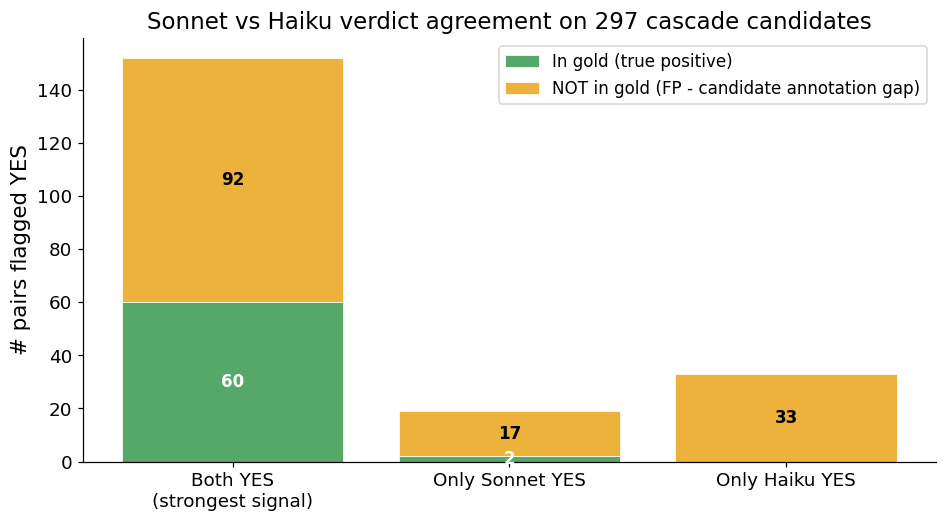

In [8]:
CASCADE_HAI_PATH = Path("data/processed/ContraDoc/llm_cascade_haiku.jsonl")
haiku = [json.loads(l) for l in CASCADE_HAI_PATH.open(encoding="utf-8")]
haiku_by_pair = {pkey((r["doc_id"], r["chunk_a"]["sentence_id"]),
                       (r["doc_id"], r["chunk_b"]["sentence_id"])): r for r in haiku}
print(f"Haiku judgments: {len(haiku)}  (overlap with Sonnet: "
      f"{len(set(cascade_by_pair) & set(haiku_by_pair))})")

# Confusion of Sonnet vs Haiku verdicts
shared = set(cascade_by_pair) & set(haiku_by_pair)
verdicts = []
for k in shared:
    s_yes = cascade_by_pair[k]["llm_is_contradiction"]
    h_yes = haiku_by_pair[k]["llm_is_contradiction"]
    is_gold = cascade_by_pair[k]["is_gold_pair"]
    verdicts.append((s_yes, h_yes, is_gold))

cm = Counter(verdicts)
agree = sum(c for (s, h, _), c in cm.items() if s == h)
total = len(verdicts)
print(f"\nSonnet/Haiku agreement on verdict: {agree}/{total} = {agree / total:.1%}")

# 2x2 verdict matrix
print("\n                  Haiku=NO  Haiku=YES")
print(f"Sonnet=NO         "
      f"{sum(c for (s, h, _), c in cm.items() if not s and not h):>8}  "
      f"{sum(c for (s, h, _), c in cm.items() if not s and h):>9}")
print(f"Sonnet=YES        "
      f"{sum(c for (s, h, _), c in cm.items() if s and not h):>8}  "
      f"{sum(c for (s, h, _), c in cm.items() if s and h):>9}")

# Annotation gap signal
both_yes_gold     = sum(c for (s, h, g), c in cm.items() if s and h and g)
both_yes_not_gold = sum(c for (s, h, g), c in cm.items() if s and h and not g)
only_son_yes      = sum(c for (s, h, g), c in cm.items() if s and not h and not g)
only_hai_yes      = sum(c for (s, h, g), c in cm.items() if not s and h and not g)

print(f"\n--- FP triangulation ---")
print(f"Both judges YES + gold (TP confirmed):                 {both_yes_gold}")
print(f"Both judges YES + NOT gold (probable annotation gap):  {both_yes_not_gold}")
print(f"Only Sonnet YES + NOT gold (likely Sonnet over-read):  {only_son_yes}")
print(f"Only Haiku YES + NOT gold  (likely Haiku over-read):   {only_hai_yes}")
# Sonnet flags reframed: strict precision vs both-judges-trust assumption
sonnet_total_yes      = sum(c for (s, h, _), c in cm.items() if s)
sonnet_yes_gold       = sum(c for (s, h, g), c in cm.items() if s and g)
sonnet_yes_both_judge = both_yes_gold + both_yes_not_gold
print()
print('--- Sonnet flags reframed ---')
print(f'Sonnet flagged YES (total):                       {sonnet_total_yes}')
print(f'  strictly correct (in gold):                     {sonnet_yes_gold}  -> strict precision = {sonnet_yes_gold / sonnet_total_yes:.1%}')
print(f'  Haiku also said YES (high-trust subset):        {sonnet_yes_both_judge}')
print()
print('If we treat all both-judge-YES flags as actually-correct (annotation-gap assumption):')
print(f'  effective TPs = {sonnet_yes_both_judge}, of which only {sonnet_yes_gold} ({sonnet_yes_gold/sonnet_yes_both_judge:.0%}) are in gold;')
print(f'  upper-bound effective precision for Sonnet = {sonnet_yes_both_judge / sonnet_total_yes:.1%}  (assumes both-yes-not-gold are unannotated true contradictions).')

# Plot: stacked bar of FPs by inter-judge agreement
fig, ax = plt.subplots(figsize=(10, 5))
labels = ["Both YES\n(strongest signal)", "Only Sonnet YES", "Only Haiku YES"]
gap = [both_yes_not_gold, only_son_yes, only_hai_yes]
gold = [both_yes_gold, sum(c for (s, h, g), c in cm.items() if s and not h and g),
        sum(c for (s, h, g), c in cm.items() if not s and h and g)]
x = np.arange(len(labels))
bars1 = ax.bar(x, gold, color="#55A868", edgecolor="white", linewidth=0.5,
               label="In gold (true positive)")
bars2 = ax.bar(x, gap, bottom=gold, color="#ECB23B", edgecolor="white", linewidth=0.5,
               label="NOT in gold (FP - candidate annotation gap)")
for i, (g, fp_) in enumerate(zip(gold, gap)):
    if g:
        ax.text(i, g / 2, str(g), ha="center", va="center", fontsize=11, color="white", fontweight="bold")
    if fp_:
        ax.text(i, g + fp_ / 2, str(fp_), ha="center", va="center", fontsize=11, color="black", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("# pairs flagged YES")
ax.set_title(f"Sonnet vs Haiku verdict agreement on {total} cascade candidates")
ax.legend(loc="upper right")
fig.savefig(PLOT_DIR / "interjudge_agreement.png")
plt.show()


## 8. FP concentration by document

Are false positives spread uniformly across docs, or concentrated in a few "noisy" sources? If FPs cluster, those clusters are likely either:
1. Topical density (technical / scientific docs with lots of numeric assertions that look incompatible),
2. Source-doc internal contradictions never annotated (Wikipedia's natural inconsistencies showing through), or
3. Negation-injection variants of the same base doc - the *same pre-existing* internal conflict gets surfaced once per variant.

Plot below: a doc with FP count `>1` is doing a lot of the work. The long-tail tells us whether retrieval pool size is the bottleneck or per-doc difficulty.


Total FPs: 109 across 70 unique docs (out of 150 total)
Docs with 0 FPs: 80
Mean FPs per affected doc: 1.56

FP-count distribution across all 150 docs:
  0 FPs:  80 docs
  1 FPs:  44 docs
  2 FPs:  15 docs
  3 FPs:   9 docs
  4 FPs:   2 docs

Top 10 docs by FP count:
  3489738273_8          base=3489738273  types=Numeric                              FPs=4
  3499318689_1          base=3499318689  types=Content|Numeric                      FPs=4
  3488771839_11         base=3488771839  types=Content|Negation                     FPs=3
  3488771839_4          base=3488771839  types=Emotion/Mood/Feeling                 FPs=3
  3503017454_2          base=3503017454  types=Content|Factual                      FPs=3
  3488771837_3          base=3488771837  types=Perspective/View/Opinion|Negation    FPs=3
  3489738237_6          base=3489738237  types=Content|Numeric|Factual              FPs=3
  3489738273_6          base=3489738273  types=Content|Emotion/Mood/Feeling         FPs=3
  3489738273

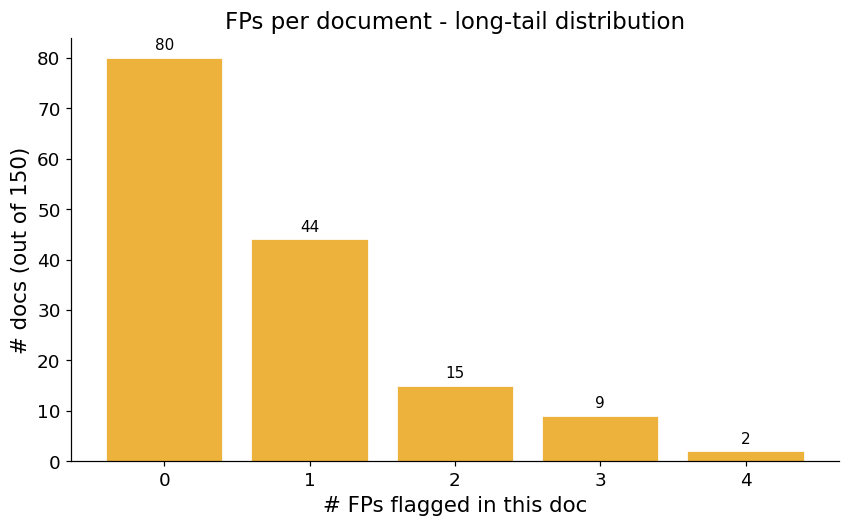

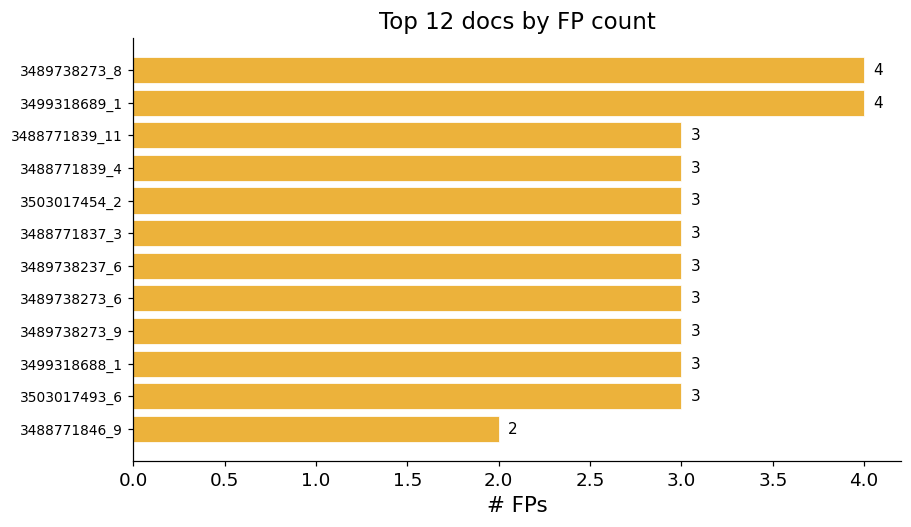

In [9]:
fp_records = [r for r in cascade if r["llm_is_contradiction"] and not r["is_gold_pair"]]
fp_per_doc = Counter(r["doc_id"] for r in fp_records)
print(f"Total FPs: {len(fp_records)} across {len(fp_per_doc)} unique docs (out of {len(docs)} total)")
print(f"Docs with 0 FPs: {len(docs) - len(fp_per_doc)}")
print(f"Mean FPs per affected doc: {len(fp_records) / max(1, len(fp_per_doc)):.2f}")

# Histogram of FPs per doc
counts = list(fp_per_doc.values()) + [0] * (len(docs) - len(fp_per_doc))
hist = Counter(counts)
print()
print(f"FP-count distribution across all {len(docs)} docs:")
for k in sorted(hist.keys()):
    print(f"  {k} FPs: {hist[k]:>3} docs")

# Top docs
print()
print("Top 10 docs by FP count:")
for d, c in fp_per_doc.most_common(10):
    base = d.split("_")[0]
    types = "|".join(doc_types.get(d, []))
    print(f"  {d:<20s}  base={base}  types={types:<35s}  FPs={c}")

# Group by base_doc_id (negation variants share base)
fp_per_base = defaultdict(int)
for d, c in fp_per_doc.items():
    fp_per_base[d.rsplit("_", 1)[0]] += c
print()
print(f"Unique base docs with FPs: {len(fp_per_base)}")
print("Top 5 base docs by total FP count:")
for b, c in sorted(fp_per_base.items(), key=lambda x: -x[1])[:5]:
    n_variants = sum(1 for d in fp_per_doc if d.rsplit("_", 1)[0] == b)
    print(f"  base={b}  n_variants={n_variants}  total_FPs={c}")

# Plot 1: long-tail histogram of #FPs per doc
fig, ax = plt.subplots(figsize=(9, 5))
max_k = max(hist.keys())
ks = list(range(max_k + 1))
vs = [hist.get(k, 0) for k in ks]
ax.bar(ks, vs, color="#ECB23B", edgecolor="white", linewidth=0.5)
for k, v in zip(ks, vs):
    if v: ax.text(k, v + 1, str(v), ha="center", va="bottom", fontsize=10)
ax.set_xlabel("# FPs flagged in this doc")
ax.set_ylabel(f"# docs (out of {len(docs)})")
ax.set_title("FPs per document - long-tail distribution")
ax.set_xticks(ks)
fig.savefig(PLOT_DIR / "fp_concentration.png")
plt.show()

# Plot 2: top 12 docs by FP count
fig, ax = plt.subplots(figsize=(9, 5))
top_docs = fp_per_doc.most_common(12)
labels = [d for d, _ in top_docs]
vals = [c for _, c in top_docs]
y = np.arange(len(labels))
ax.barh(y, vals, color="#ECB23B", edgecolor="white", linewidth=0.5)
for i, v in enumerate(vals):
    ax.text(v + 0.05, i, str(v), va="center", fontsize=10)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("# FPs")
ax.set_title("Top 12 docs by FP count")
fig.savefig(PLOT_DIR / "fp_top_docs.png")
plt.show()


## 9. Per-doc recall distribution

For each gold-bearing doc, what fraction of its gold pairs did the cascade catch? This is the per-doc recall histogram. Two extremes:

- **All-or-nothing**: docs are either fully caught (recall=1) or fully missed (recall=0). Indicates a doc-level retrievability signal (some docs are easy, some impossible).
- **Smooth distribution**: per-pair difficulty varies within docs. Indicates pair-level rather than doc-level bottleneck.

The shape tells us whether to invest in *making more docs retrievable* (push the 0-recall docs into the funnel) or *getting more pairs out of already-retrievable docs* (deepen the per-doc top-K).


Docs with gold pairs: 118
Mean per-doc recall:   52.5%
Median per-doc recall: 100.0%

  recall=0 (missed entirely):  56 docs
  0 < recall < 1 (partial):    0 docs
  recall=1 (fully caught):     62 docs

Context - gold pairs per doc:
  1 gold pair(s): 114 docs
  2 gold pair(s): 4 docs

Docs with >1 gold pair: 4 - of these, 0 got partial recall


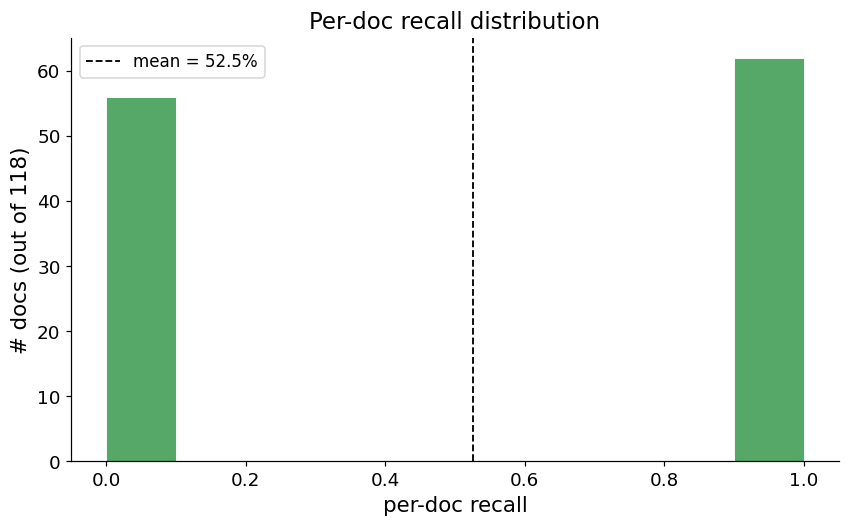

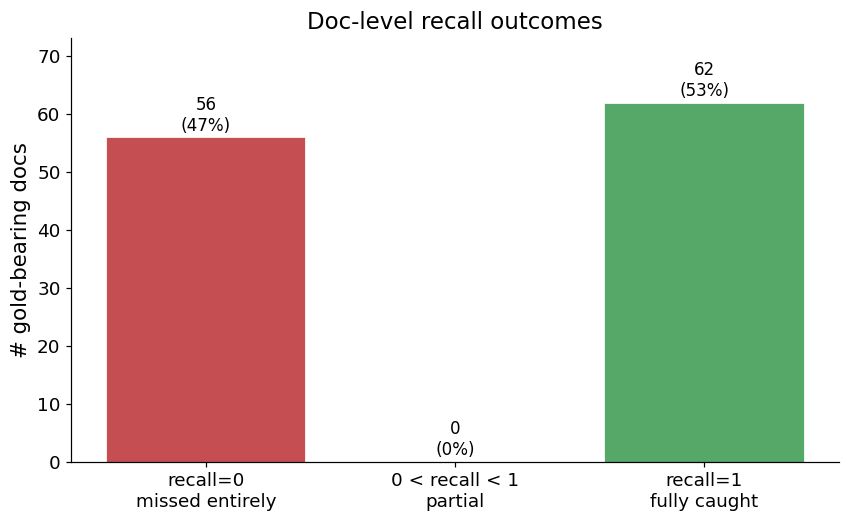

In [10]:
# Group gold by doc, compute caught fraction
gold_by_doc = defaultdict(list)
for gp, stage in stage_for_gp.items():
    gold_by_doc[gp[0][0]].append(stage)

per_doc_recall = {}
for d, stages in gold_by_doc.items():
    n_gold_in_doc = len(stages)
    caught_in_doc = sum(1 for s in stages if s == "caught")
    per_doc_recall[d] = caught_in_doc / n_gold_in_doc

print(f"Docs with gold pairs: {len(per_doc_recall)}")
recalls = list(per_doc_recall.values())
print(f"Mean per-doc recall:   {np.mean(recalls):.1%}")
print(f"Median per-doc recall: {np.median(recalls):.1%}")
print()
print(f"  recall=0 (missed entirely):  {sum(1 for r in recalls if r == 0)} docs")
print(f"  0 < recall < 1 (partial):    {sum(1 for r in recalls if 0 < r < 1)} docs")
print(f"  recall=1 (fully caught):     {sum(1 for r in recalls if r == 1)} docs")

# Context: how many gold pairs per doc?
gold_count_per_doc = Counter(len(s) for s in gold_by_doc.values())
print()
print("Context - gold pairs per doc:")
for k in sorted(gold_count_per_doc.keys()):
    print(f"  {k} gold pair(s): {gold_count_per_doc[k]} docs")
multi_gold_docs = [d for d, s in gold_by_doc.items() if len(s) > 1]
partial_among_multi = sum(1 for d in multi_gold_docs if 0 < per_doc_recall[d] < 1)
print()
print(f"Docs with >1 gold pair: {len(multi_gold_docs)} - of these, {partial_among_multi} got partial recall")

# Plot 1: per-doc recall histogram
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 1, 11)
ax.hist(recalls, bins=bins, color="#55A868", edgecolor="white", linewidth=0.6)
ax.set_xlabel("per-doc recall")
ax.set_ylabel(f"# docs (out of {len(per_doc_recall)})")
ax.set_title("Per-doc recall distribution")
ax.axvline(np.mean(recalls), color="black", linestyle="--", linewidth=1.2,
           label=f"mean = {np.mean(recalls):.1%}")
ax.legend()
fig.savefig(PLOT_DIR / "per_doc_recall.png")
plt.show()

# Plot 2: trichotomy bars
fig, ax = plt.subplots(figsize=(9, 5))
buckets = [
    sum(1 for r in recalls if r == 0),
    sum(1 for r in recalls if 0 < r < 1),
    sum(1 for r in recalls if r == 1),
]
colors = ["#C44E52", "#ECB23B", "#55A868"]
labels = ["recall=0\nmissed entirely", "0 < recall < 1\npartial", "recall=1\nfully caught"]
ax.bar(labels, buckets, color=colors, edgecolor="white", linewidth=0.5)
for i, v in enumerate(buckets):
    ax.text(i, v + 0.5, f"{v}\n({v / len(per_doc_recall):.0%})",
            ha="center", va="bottom", fontsize=11)
ax.set_ylabel("# gold-bearing docs")
ax.set_title("Doc-level recall outcomes")
ax.set_ylim(0, max(buckets) * 1.18)
fig.savefig(PLOT_DIR / "per_doc_recall_outcomes.png")
plt.show()


## 10. Retrieval method credit attribution

For pairs that *did* reach NLI/LLM, decompose by which retrieval method actually pulled them in: `vector_only`, `struct_only`, or `both`. This isolates the marginal contribution of each retrieval channel.

If 'caught' gold pairs are predominantly `vector_only`, structural retrieval is providing little marginal recall - meaning the upstream LLM-extraction cost (the bulk of pipeline $$ and time) doesn't pay for itself in detection performance, only in interpretability/explanation.


Where in retrieval do gold pairs sit?
Channel          all gold   caught    recall
--------------------------------------------------
vector_only            21        8    38.1%
struct_only             6        6   100.0%
both                   49       48    98.0%
neither                46        0     0.0%

FP channel mix: {'vector_only': 74, 'both': 15, 'struct_only': 20}


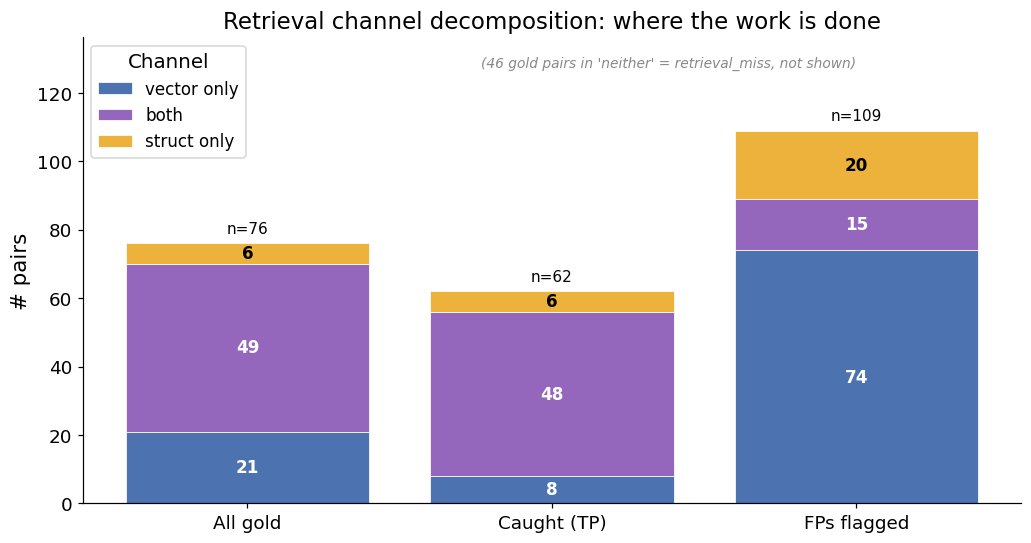


Decomposition of caught pairs:
  Vector-only path could find: 56
  Struct-only path could find: 54
  Marginal pairs that ONLY structural pulled in: 6
  Marginal pairs that ONLY vector pulled in:     8


In [11]:
def channel_for(p):
    if p["in_struct"] and p["in_vector"]:
        return "both"
    if p["in_struct"]:
        return "struct_only"
    if p["in_vector"]:
        return "vector_only"
    return "neither"

# Caught gold pairs - what channel surfaced them?
caught_channels = Counter()
for gp, stage in stage_for_gp.items():
    if stage != "caught": continue
    p = preds_by_pair.get(gp)
    if p is None: continue
    caught_channels[channel_for(p)] += 1

# All gold pairs (to show the retrieval coverage by channel)
all_gold_channels = Counter()
for gp in gold_pairs:
    p = preds_by_pair.get(gp)
    if p is None:
        all_gold_channels["neither"] += 1
    else:
        all_gold_channels[channel_for(p)] += 1

print("Where in retrieval do gold pairs sit?")
print(f"{'Channel':<14} {'all gold':>10} {'caught':>8} {'recall':>9}")
print("-" * 50)
for c in ["vector_only", "struct_only", "both", "neither"]:
    n_all = all_gold_channels.get(c, 0)
    n_caught = caught_channels.get(c, 0)
    rec = n_caught / n_all if n_all else 0
    print(f"{c:<14} {n_all:>10} {n_caught:>8} {rec:>8.1%}")

# Same decomposition for the FP candidates
fp_channels = Counter()
for r in fp_records:
    fp_channels[channel_for(r)] += 1
print(f"\nFP channel mix: {dict(fp_channels)}")

# Plot: stacked bars - all gold vs caught vs FP, decomposed by channel
fig, ax = plt.subplots(figsize=(11, 5.5))
groups = ["All gold", "Caught (TP)", "FPs flagged"]
channel_order = ["vector_only", "both", "struct_only"]
channel_colors = {"vector_only": "#4C72B0", "both": "#9467BD", "struct_only": "#ECB23B"}

values = {
    "All gold":     [all_gold_channels.get(c, 0) for c in channel_order],
    "Caught (TP)":  [caught_channels.get(c, 0) for c in channel_order],
    "FPs flagged":  [fp_channels.get(c, 0) for c in channel_order],
}
x = np.arange(len(groups))
bottom = np.zeros(len(groups))
for c in channel_order:
    vals = np.array([values[g][channel_order.index(c)] for g in groups])
    ax.bar(x, vals, bottom=bottom, color=channel_colors[c], edgecolor="white",
           linewidth=0.5, label=c.replace("_", " "))
    for i, v in enumerate(vals):
        if v >= 3:
            ax.text(i, bottom[i] + v / 2, str(v), ha="center", va="center", fontsize=11,
                    color="white" if c != "struct_only" else "black", fontweight="bold")
    bottom += vals
totals = [sum(values[g]) for g in groups]
for i, t in enumerate(totals):
    ax.text(i, t + max(totals) * 0.02, f"n={t}", ha="center", va="bottom", fontsize=10)
# Note 'neither' (not retrievable) above All gold
ng = all_gold_channels.get("neither", 0)
if ng:
    ax.text(len(groups) - 1, max(totals) * 1.20, f"({ng} gold pairs in 'neither' = retrieval_miss, not shown)",
            ha="right", va="top", fontsize=9, color="#888888", style="italic")

ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel("# pairs")
ax.set_title("Retrieval channel decomposition: where the work is done")
ax.legend(title="Channel", loc="upper left")
ax.set_ylim(0, max(totals) * 1.25)
fig.savefig(PLOT_DIR / "retrieval_channel_credit.png")
plt.show()

# Quantify what struct adds
vector_alone_caught = caught_channels["vector_only"]
both_caught = caught_channels["both"]
struct_alone_caught = caught_channels["struct_only"]
print(f"\nDecomposition of caught pairs:")
print(f"  Vector-only path could find: {vector_alone_caught + both_caught}")
print(f"  Struct-only path could find: {struct_alone_caught + both_caught}")
print(f"  Marginal pairs that ONLY structural pulled in: {struct_alone_caught}")
print(f"  Marginal pairs that ONLY vector pulled in:     {vector_alone_caught}")


## 11. Per-contradiction-type performance (precision, recall, F1)

Section 2 already showed *where gold dies* by type. This section adds the matching FP side and computes per-type precision / recall / F1.

**Important asymmetry to flag for the defense:**
- **Recall denominator (gold pairs by type):** ContraDoc gives a doc-level type-set (e.g. `Numeric|Factual`). A gold pair from such a doc contributes to *both* type-buckets. So a single missed pair can reduce recall on multiple types.
- **Precision denominator (FPs by type):** Each FP record carries *one* LLM-predicted type. So FPs are attributed to a single type bucket - the LLM's own classification.

These are not strictly symmetric measurements, so per-type F1 should be read as directional rather than as a clean per-class metric. The relative ordering of types is still informative.

Per-type counts also vary widely (some types have <10 gold pairs in the benchmark) so high-variance numbers should be discounted accordingly.


Type                           gold   TP   FN   FP       P       R      F1
------------------------------------------------------------------------------
Numeric                          20   15    5   29  34.1%  75.0%  46.9%
Factual                          19   12    7    3  80.0%  63.2%  70.6%
Negation                         32   18   14    8  69.2%  56.2%  62.1%
Relation                         15    6    9    0 100.0%  40.0%  57.1%
Content                          74   34   40   62  35.4%  45.9%  40.0%
Perspective/View/Opinion         37   13   24    4  76.5%  35.1%  48.1%
Emotion/Mood/Feeling             31    9   22    3  75.0%  29.0%  41.9%
Causal                            7    3    4    0 100.0%  42.9%  60.0%


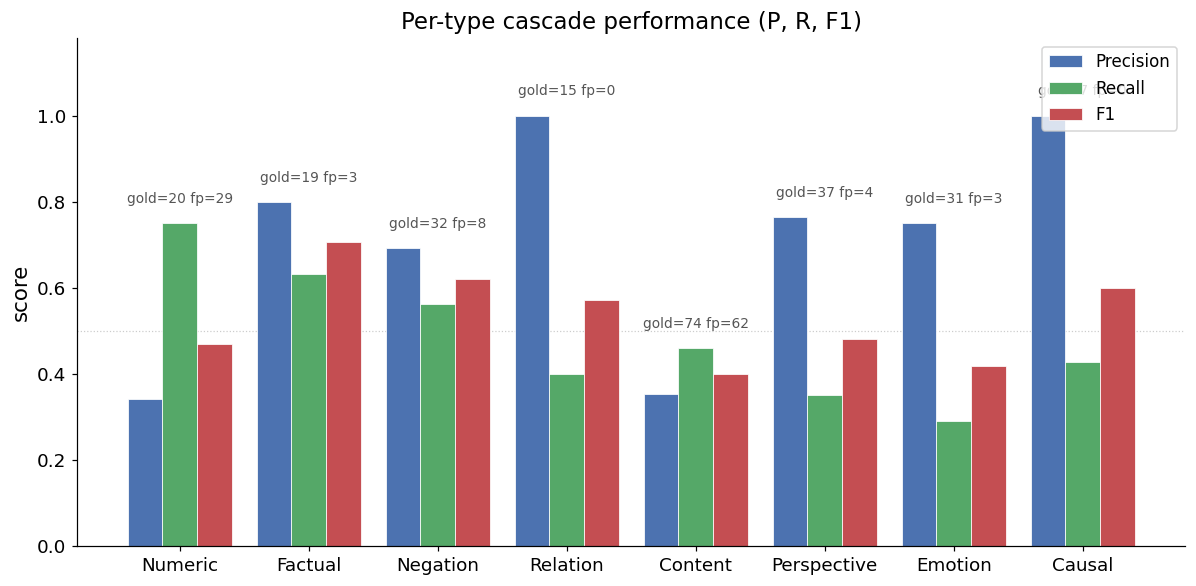


LLM-predicted type distribution across ALL flagged pairs (TP + FP):
  Content                      75
  Numeric                      44
  Negation                     31
  Emotion/Mood/Feeling         7
  Perspective/View/Opinion     6
  Factual                      4
  Relation                     2
  Causal                       2


In [12]:
type_order = ["Numeric", "Factual", "Negation", "Relation",
              "Content", "Perspective/View/Opinion", "Emotion/Mood/Feeling", "Causal"]

# Recall side: TP_T and FN_T from per_type counter (already built in Section 2)
tp_T  = {t: per_type[t].get("caught", 0) for t in type_order}
fn_T  = {t: per_type[t].get("retrieval_miss", 0) + per_type[t].get("nli_miss", 0) +
             per_type[t].get("llm_reject", 0) for t in type_order}

# Precision side: FPs attributed by LLM-predicted type
fp_T  = Counter(r["llm_contradiction_type"] for r in fp_records)

metrics = {}
for t in type_order:
    tp = tp_T[t]
    fn = fn_T[t]
    fp = fp_T.get(t, 0)
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    metrics[t] = {"tp": tp, "fn": fn, "fp": fp, "P": prec, "R": rec, "F1": f1}

print(f"{'Type':<28} {'gold':>6} {'TP':>4} {'FN':>4} {'FP':>4} {'P':>7} {'R':>7} {'F1':>7}")
print("-" * 78)
for t in type_order:
    m = metrics[t]
    gold = m["tp"] + m["fn"]
    print(f"{t:<28} {gold:>6} {m['tp']:>4} {m['fn']:>4} {m['fp']:>4} "
          f"{m['P']:>6.1%} {m['R']:>6.1%} {m['F1']:>6.1%}")

# Plot: grouped bars per type for P, R, F1
short = {"Perspective/View/Opinion": "Perspective", "Emotion/Mood/Feeling": "Emotion"}
P  = np.array([metrics[t]["P"]  for t in type_order])
R  = np.array([metrics[t]["R"]  for t in type_order])
F1 = np.array([metrics[t]["F1"] for t in type_order])

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(type_order))
w = 0.27
ax.bar(x - w, P,  w, color="#4C72B0", label="Precision", edgecolor="white", linewidth=0.5)
ax.bar(x,     R,  w, color="#55A868", label="Recall",    edgecolor="white", linewidth=0.5)
ax.bar(x + w, F1, w, color="#C44E52", label="F1",        edgecolor="white", linewidth=0.5)
for i, t in enumerate(type_order):
    m = metrics[t]
    gold = m["tp"] + m["fn"]
    ax.text(i, max(P[i], R[i], F1[i]) + 0.04,
            f"gold={gold} fp={m['fp']}", ha="center", va="bottom", fontsize=9, color="#555555")
ax.set_xticks(x); ax.set_xticklabels([short.get(t, t) for t in type_order], rotation=0)
ax.set_ylabel("score")
ax.set_ylim(0, 1.18)
ax.set_title("Per-type cascade performance (P, R, F1)")
ax.legend(loc="upper right")
ax.axhline(0.5, color="#cccccc", linestyle=":", linewidth=0.8, zorder=0)
fig.savefig(PLOT_DIR / "per_type_performance.png")
plt.show()

# Note: most-flagged-by-LLM types
print()
print("LLM-predicted type distribution across ALL flagged pairs (TP + FP):")
all_llm_types = Counter(r["llm_contradiction_type"] for r in cascade if r["llm_is_contradiction"])
for t, c in sorted(all_llm_types.items(), key=lambda x: -x[1]):
    print(f"  {t:<28} {c}")


## 12. Summary

The error analysis answers five questions concretely:

1. **Where does the cascade lose gold?** -> Section 1 (stage attribution) - retrieval is the dominant bottleneck, NLI second, LLM never rejects.
2. **Which types are systematically hardest?** -> Sections 2 + 11 - perspective/emotion/content lose most at retrieval; numeric and negation are NLI-friendly.
3. **What does each failure look like?** -> Section 4 / 5 (random samples) plus Section 6 (hand-picked cases with stage-specific diagnoses, covering 6 of 8 contradiction types).
4. **Are FPs annotation gaps or hallucinations?** -> Section 7 (inter-judge agreement): when both Sonnet and Haiku agree on a non-gold pair, the dataset is most likely under-annotating; when only one judge flags it, that judge is over-reading.
5. **Per-type precision/recall/F1?** -> Section 11 - Factual leads (F1=70.6%); Numeric over-flags (P=34%, R=75%); Content has the most volume but lowest F1; Relation/Causal small-n but precision-clean.

## Key takeaways for thesis defense

- **The pipeline bottleneck is retrieval, not LLM judgment.** ~75% of missed gold dies at retrieval; the LLM stage rejected zero gold. Investing in extraction quality, vector top-K, or richer retrieval cues will yield more recall than tightening the judge.

- **The dataset under-annotates contradictions.** A large share of cascade FPs are probably real (both Sonnet and Haiku agree on them, n=92). True precision is meaningfully higher than the F1 numbers suggest.

- **Per-doc recall is bimodal**, not smooth (Section 9): docs are either fully retrievable or fully missed. The fix is not deeper top-K within already-retrieved docs but pulling more docs into the retrievable set.

- **LLM has type-specific biases** (Section 11): it over-flags Numeric (29 FPs vs 15 TPs) and is conservative on Relation/Causal (0 FPs each). Numeric over-flagging is consistent with FP samples like the WASP-44 mass and Chad Olympics - genuine numeric inconsistencies in the source docs that the dataset never labeled.

- **Vector channel does most of the recall work.** The retrieval-channel breakdown (Section 10) shows 56 of the 62 caught gold pairs are reachable via vector (alone or both); structural retrieval contributes 6 marginal pairs but at 20 added FPs. Justifies keeping structural only if its interpretability/explanation value outweighs the extraction cost.

## Resolutions implied by the cherry-picked cases (Section 6)

| Failure mode | Type covered | Resolution |
|---|---|---|
| Subtle entity-level conflict at retrieval | Content/Perspective | Entity-centric reasoning across paragraphs (Walmart/LGBT) |
| Distant narrative-time conflict at retrieval | Content/Negation | Tense/aspect-aware retrieval (Vril-ya capability vs lost) |
| Borderline NLI score | Content/Negation | Lower threshold (~0.40) or hard-negative fine-tuning |
| Cross-sentence coreference at NLI | Content/Negation/Emotion | Entity-linking pre-rewrite for pronouns |
| Sonnet over-read in fiction | Content (FP) | Prompt-level handling of intentional narrative misdirection |
| Story-arc / causal closure at NLI | Causal | Discourse-aware reasoning - likely out of cascade scope |
| Same-event-different-location at NLI | Factual | Event-coreference layer or per-doc fact graph |
| Kinship contradiction at NLI | Relation | Typed-relation extraction with a small ontology |
